# UpSet plots & intersections

In [127]:
import os
import sys
import glob
import warnings
import openpyxl
from upsetplot import UpSet, from_contents
import matplotlib.pyplot as plt
import pandas as pd

# Ensure the src directory is in the Python path
scripts = os.path.abspath('')
src_path = os.path.abspath(os.path.join(scripts, '..', 'src'))
if src_path not in sys.path:
    sys.path.append(src_path)

from hyphy_results_parser import (
    RelaxResult,
    BustedPhResult
)

import get_silk_genes as silk
from id_converter import convert_locs_to_hogs, convert_hogs_to_locs

from odds_ratio_test import BootstrapTestResults

# Define paths to data and results directories
data = os.path.join(scripts, "..", "data")
figures = os.path.join(scripts, "..", "figures")
assets = os.path.join(scripts, "..", "assets")
results = os.path.join(scripts, "..", "results")

# Suppress FutureWarnings and SyntaxWarnings from libraries (especially upsetplot)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=SyntaxWarning)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Read all the hit lists into a dictionary (as HOGs)

In [128]:
hits_lists = {}

### Silk gland genes & spidroins

In [129]:
silk_genes_list = silk.get_all_silk_genes(top10=False)
spidroins_list = pd.read_csv(f'{assets}/spidroins_LOCs.tsv', sep='\t', dtype=str)['LOC'].tolist()

# There may end up being LOCs in these HOGs that are not in my silk gland gene list
# or spidroin list. However, if they are orthologous to those LOCs, they are still relevant.
silk_hogs = convert_locs_to_hogs(silk_genes_list, f'{assets}/N5.tsv')
spidroin_hogs = convert_locs_to_hogs(spidroins_list, f'{assets}/N5.tsv')

# These lists of HOGs are longer than the original lists of LOCs, meaning some LOCs 
# belong to multiple HOGs. This may be because multiple isoforms of the gene were 
# included in the original Orthofinder analysis.
hits_lists['silk_genes'] = list(set(silk_hogs['HOG'].tolist()))
hits_lists['spidroins'] = list(set(spidroin_hogs['HOG'].tolist()))

### Hyphy results

In [130]:
hyphy_results = results + "/hyphy_results_cache/"

# Load the saved RELAX results
relax_result = RelaxResult.load_from_pickle(str(hyphy_results + "relax_results.pkl"))
relax_result_fltrd = relax_result.filter_omega(10000)
relax_df_fltrd = relax_result_fltrd.results_df
hits_lists['relaxed_in_nonorb'] = list(relax_df_fltrd[relax_df_fltrd['result']=='relaxed'].index)
hits_lists['intensified_in_nonorb'] = list(relax_df_fltrd[relax_df_fltrd['result']=='intensified'].index)

# Load the saved BUSTED-PH results
busted_ph_result = BustedPhResult.load_from_pickle(str(hyphy_results + "busted_ph_results.pkl"))
busted_ph_result_fltrd = busted_ph_result.filter_omega(10000)
busted_ph_df_fltrd = busted_ph_result_fltrd.results_df
hits_lists['positive_sel_in_orb'] = list(busted_ph_df_fltrd[busted_ph_df_fltrd['result']=='hit'].index)

# Load the saved BUSTED-PH-REV results
busted_ph_rev_result = BustedPhResult.load_from_pickle(str(hyphy_results + "busted_ph_rev_results.pkl"))


busted_ph_rev_result_fltrd = busted_ph_rev_result.filter_omega(10000)
busted_ph_rev_df_fltrd = busted_ph_rev_result_fltrd.results_df
hits_lists['positive_sel_in_nonorb'] = list(busted_ph_rev_df_fltrd[busted_ph_rev_df_fltrd['result']=='hit'].index)

### Odds ratio test results

Using the left-tailed results arbitrarily, since both runs of the test produced lists of significant hogs on both sides. (Left-tailed vs right-tailed refers to whether the overall distributions were significantly different, not whether or not individual HOGs were favored by orb-weavers or non-orbweavers)

In [131]:
ort_50_dir = results + "/odds_ratio_test/occ_50"
ort_75_dir = results + "/odds_ratio_test/occ_75"

# Duplication results
duplication_ort_50 = BootstrapTestResults.load_from_pickle(f'{ort_50_dir}/duplication_RT/duplication_occ50-98_RT.pkl')
dup_50_df = duplication_ort_50.results_fltrd_df

duplication_ort_75 = BootstrapTestResults.load_from_pickle(f'{ort_75_dir}/duplication_RT/duplication_occ75-98_RT.pkl')
dup_75_df = duplication_ort_75.results_fltrd_df

# Loss results
loss_ort_50 = BootstrapTestResults.load_from_pickle(f'{ort_50_dir}/loss_LT/loss_occ50-95_LT.pkl')
loss_50_df = loss_ort_50.results_fltrd_df

loss_ort_75 = BootstrapTestResults.load_from_pickle(f'{ort_75_dir}/loss_LT/loss_occ75-95_LT.pkl')
loss_75_df = loss_ort_75.results_fltrd_df

Confirming that the 2 runs of each bootstrap test (left-tailed and right-tailed) designated the same set of orthogroups as significant

In [132]:
# Duplication results
duplication_ort_50_l = BootstrapTestResults.load_from_pickle(f'{ort_50_dir}/duplication_LT/duplication_occ50-98_LT.pkl')
dup_50_df_l = duplication_ort_50_l.results_fltrd_df

duplication_ort_75_l = BootstrapTestResults.load_from_pickle(f'{ort_75_dir}/duplication_LT/duplication_occ75-98_LT.pkl')
dup_75_df_l = duplication_ort_75_l.results_fltrd_df

# Loss results
loss_ort_50_r = BootstrapTestResults.load_from_pickle(f'{ort_50_dir}/loss_RT/loss_occ50-95_RT.pkl')
loss_50_df_r = loss_ort_50_r.results_fltrd_df

loss_ort_75_r = BootstrapTestResults.load_from_pickle(f'{ort_75_dir}/loss_RT/loss_occ75-95_RT.pkl')
loss_75_df_r = loss_ort_75_r.results_fltrd_df

In [133]:
print(
    dup_50_df.equals(dup_50_df_l),
    dup_75_df.equals(dup_75_df_l),
    loss_50_df.equals(loss_50_df_r),
    loss_75_df.equals(loss_75_df_r),
)

False True False True


Not quite for the occupancy 50 cases -- the test results themselves were not identical; they produced different but very similar bootstrapped alpha thresholds.

In [134]:
print(
    loss_ort_50.ci_av,
    loss_ort_50_r.ci_av
)

print(
    duplication_ort_50.ci_av,
    duplication_ort_50_l.ci_av
)

[-1.38433089  1.38801583] [-1.38416918  1.38244859]
[-1.52977679  1.53390291] [-1.53070761  1.53478059]


Break down into HOGs that were more likely to be missing or in multiple copies in orbweavers or in non-orbweavers

In [135]:
hits_lists_50 = hits_lists.copy()
hits_lists_75 = hits_lists.copy()

In [136]:
hits_lists_50['duplication_more_likely_orb'] = list(dup_50_df[dup_50_df["Log odds ratio"] > 0].index)
hits_lists_50['duplication_more_likely_nonorb'] = list(dup_50_df[dup_50_df["Log odds ratio"] < 0].index)
hits_lists_50['loss_more_likely_orb'] = list(loss_50_df[loss_50_df["Log odds ratio"] > 0].index)
hits_lists_50['loss_more_likely_nonorb'] = list(loss_50_df[loss_50_df["Log odds ratio"] < 0].index)

hits_lists_75['dup_75_orb'] = list(dup_75_df[dup_75_df["Log odds ratio"] > 0].index)
hits_lists_75['dup_75_nonorb'] = list(dup_75_df[dup_75_df["Log odds ratio"] < 0].index)
hits_lists_75['loss_75_orb'] = list(loss_75_df[loss_75_df["Log odds ratio"] > 0].index)
hits_lists_75['loss_75_nonorb'] = list(loss_75_df[loss_75_df["Log odds ratio"] < 0].index)

## UpSet plot of Hyphy results only

In [137]:
hyphy_upset_dict = {
    'Positive selection ~ orbweaving': hits_lists['positive_sel_in_orb'],
    'Positive selection ~ $\it{non}$-orbweaving': hits_lists['positive_sel_in_nonorb'],
    'Selection $\it{relaxed}$ in non-orbweavers': hits_lists['relaxed_in_nonorb'],
    'Selection $\it{intensified}$ in non-orbweavers': hits_lists['intensified_in_nonorb'],
}

upset_data = from_contents(hyphy_upset_dict)

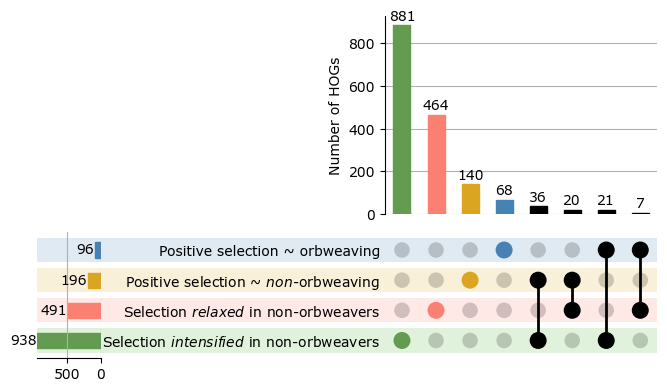

In [138]:
upset = UpSet(
    upset_data, show_counts=True,
)

upset.style_categories('Selection $\it{relaxed}$ in non-orbweavers', bar_facecolor='#FA8072', shading_facecolor='#FEE9E7')
upset.style_categories('Positive selection ~ orbweaving', bar_facecolor='#4682B4', shading_facecolor='#E0EAF2')
upset.style_categories('Positive selection ~ $\it{non}$-orbweaving', bar_facecolor='#DAA520', shading_facecolor='#F9F0D9')
upset.style_categories('Selection $\it{intensified}$ in non-orbweavers', bar_facecolor='#639B51', shading_facecolor='#E0F2DB')

upset.style_subsets(present=['Selection $\it{relaxed}$ in non-orbweavers'], 
                    absent=['Positive selection ~ orbweaving', 'Positive selection ~ $\it{non}$-orbweaving', 'Selection $\it{intensified}$ in non-orbweavers'],
                    facecolor='#FA8072')
upset.style_subsets(present=['Positive selection ~ orbweaving'], 
                    absent=['Selection $\it{relaxed}$ in non-orbweavers', 'Positive selection ~ $\it{non}$-orbweaving', 
                            'Selection $\it{intensified}$ in non-orbweavers'],
                    facecolor='#4682B4')
upset.style_subsets(present=['Selection $\it{intensified}$ in non-orbweavers'], 
                    absent=['Selection $\it{relaxed}$ in non-orbweavers', 'Positive selection ~ orbweaving', 'Positive selection ~ $\it{non}$-orbweaving'],
                    facecolor='#639B51')
upset.style_subsets(present=['Positive selection ~ $\it{non}$-orbweaving'], 
                    absent=['Selection $\it{relaxed}$ in non-orbweavers', 'Positive selection ~ orbweaving', 'Selection $\it{intensified}$ in non-orbweavers'],
                    facecolor='#DAA520')

upset.plot()
plt.ylabel('Number of HOGs')
plt.rcParams['font.family'] = 'Verdana'
plt.savefig(str(figures + '/figure_3/hyphy_upset.png'), dpi=300, transparent=False, bbox_inches='tight')

## UpSet plot of Hyphy results + silk genes/spidroins

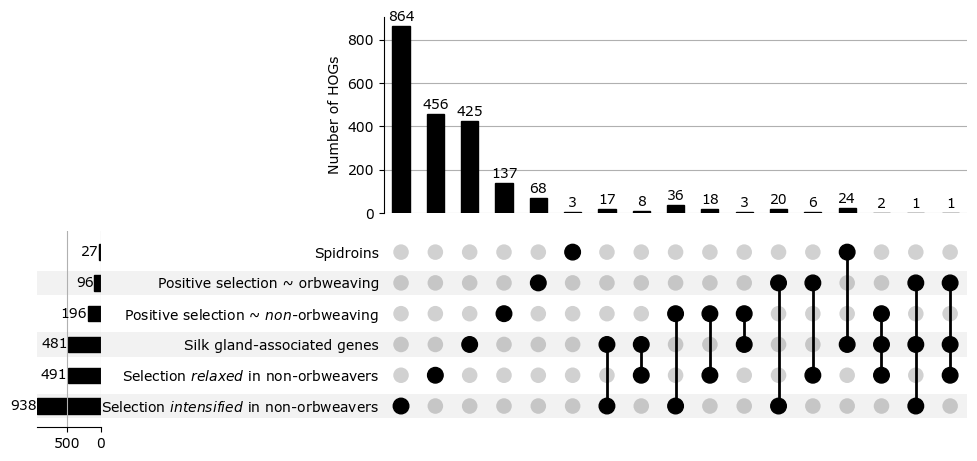

In [139]:
upset_dict_with_silk = hyphy_upset_dict.copy()
upset_dict_with_silk['Silk gland-associated genes'] = hits_lists['silk_genes']
upset_dict_with_silk['Spidroins'] = hits_lists['spidroins']

upset_data_with_silk = from_contents(upset_dict_with_silk)

upset = UpSet(
    upset_data_with_silk, show_counts=True,
)

upset.plot()
plt.ylabel('Number of HOGs')
plt.rcParams['font.family'] = 'Verdana'


# Odds ratio test upset

Text(0.5, 1.0, 'Odds ratio test (occ > 50)')

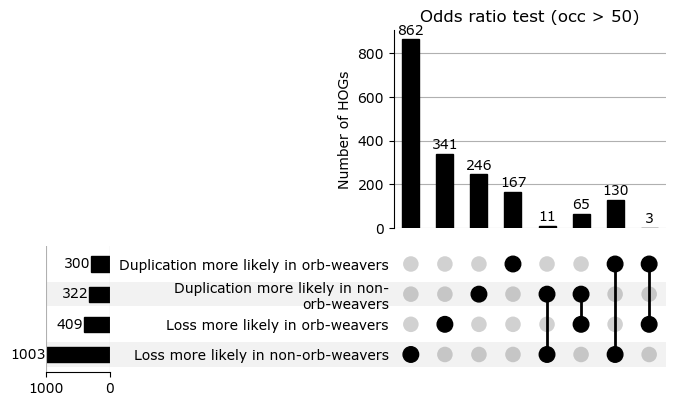

In [140]:
upset_dict_with_ort_50 = {}

upset_dict_with_ort_50['Loss more likely in non-orb-weavers'] = hits_lists_50['loss_more_likely_nonorb']
upset_dict_with_ort_50['Loss more likely in orb-weavers'] = hits_lists_50['loss_more_likely_orb']
upset_dict_with_ort_50['Duplication more likely in non-\norb-weavers'] = hits_lists_50['duplication_more_likely_nonorb']
upset_dict_with_ort_50['Duplication more likely in orb-weavers'] = hits_lists_50['duplication_more_likely_orb']


upset_data_with_ort_50 = from_contents(upset_dict_with_ort_50)

upset = UpSet(
    upset_data_with_ort_50, show_counts=True,
)

upset.plot()
plt.ylabel('Number of HOGs')
plt.rcParams['font.family'] = 'Verdana'
plt.title('Odds ratio test (occ > 50)')


Text(0.5, 1.0, 'Odds ratio test (occ > 75)')

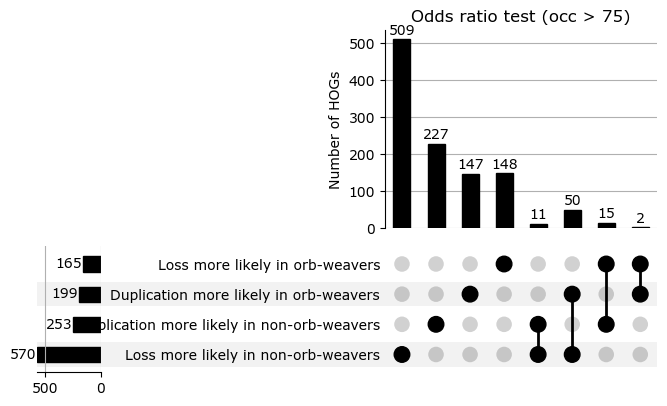

In [141]:
upset_dict_with_ort_75 = {}
upset_dict_with_ort_75['Loss more likely in orb-weavers'] = hits_lists_75['loss_75_orb']
upset_dict_with_ort_75['Loss more likely in non-orb-weavers'] = hits_lists_75['loss_75_nonorb']
upset_dict_with_ort_75['Duplication more likely in orb-weavers'] = hits_lists_75['dup_75_orb']
upset_dict_with_ort_75['Duplication more likely in non-orb-weavers'] = hits_lists_75['dup_75_nonorb']

upset_data_with_ort_75 = from_contents(upset_dict_with_ort_75)

upset = UpSet(
    upset_data_with_ort_75, show_counts=True,
)

upset.plot()
plt.ylabel('Number of HOGs')
plt.rcParams['font.family'] = 'Verdana'
plt.title('Odds ratio test (occ > 75)')


## Odds ratio test upset with silk genes/spidroins

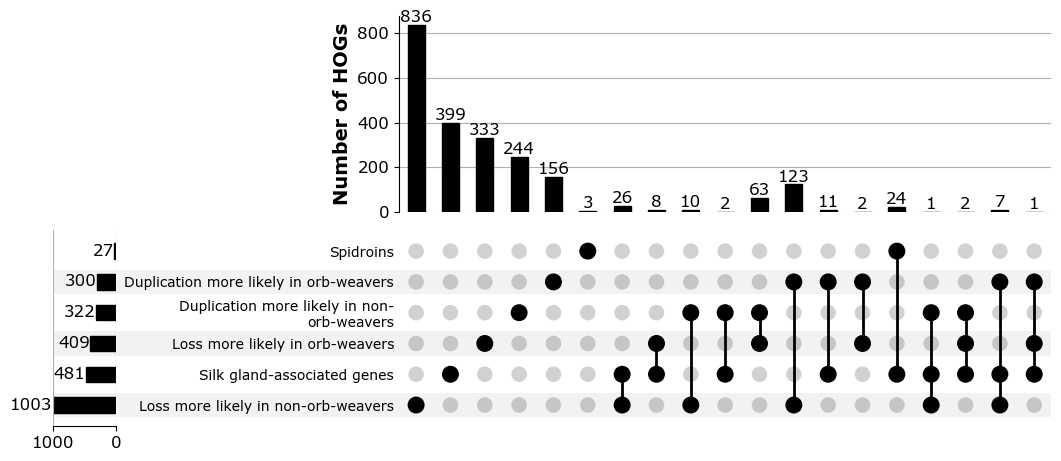

In [142]:
upset_dict_with_silk_ort_50 = upset_dict_with_ort_50.copy()
upset_dict_with_silk_ort_50['Silk gland-associated genes'] = hits_lists['silk_genes']
upset_dict_with_silk_ort_50['Spidroins'] = hits_lists['spidroins']

upset_data_with_silk_ort_50 = from_contents(upset_dict_with_silk_ort_50)

upset = UpSet(
    upset_data_with_silk_ort_50, show_counts=False,
)

upset.plot()
plt.ylabel('Number of HOGs', fontsize=14, fontweight='bold')
plt.rcParams['font.family'] = 'Verdana'
plt.tick_params(axis='y', labelsize=12)

for ax in plt.gcf().axes:
    for bar in ax.containers:
        ax.bar_label(bar, fontsize=12)  # Bar numerical labels top
    if hasattr(ax, 'get_xticklabels'):
        plt.setp(ax.get_xticklabels(), fontsize=12) # Bar numerical labels bottom

plt.savefig(str(figures + '/figure_5/ort_silk_upset_plot.png'), dpi=300, transparent=False, bbox_inches='tight')


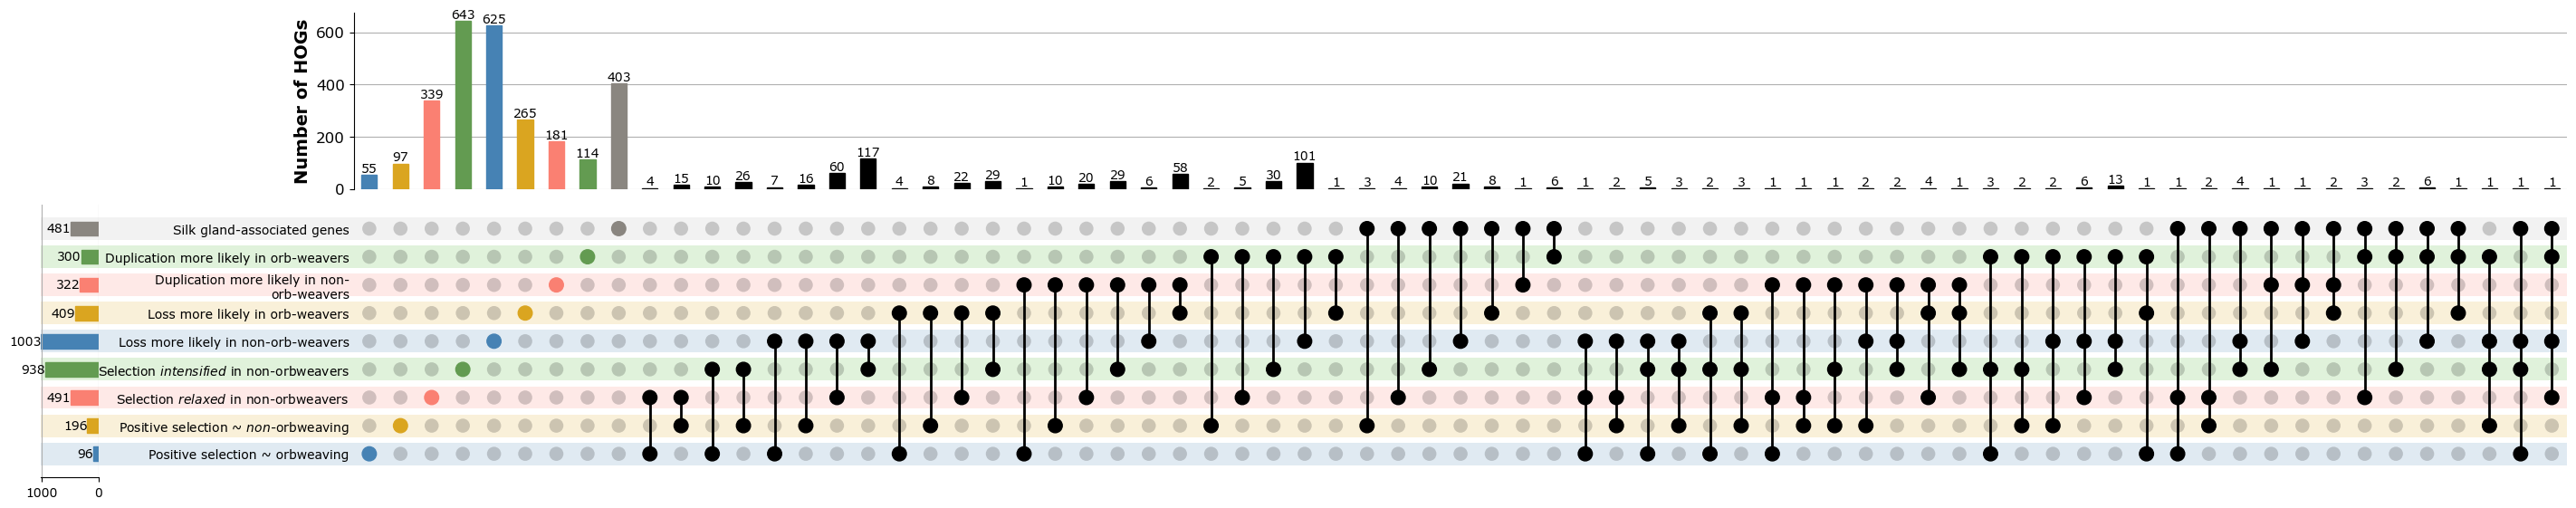

In [152]:
upset_dict_massive_50 = hyphy_upset_dict | upset_dict_with_ort_50
# upset_dict_massive_50 = dict(reversed(list(upset_dict_massive_50.items())))
upset_dict_massive_50['Silk gland-associated genes'] = hits_lists['silk_genes']


upset_data_massive = from_contents(upset_dict_massive_50)

upset = UpSet(
    upset_data_massive,
    sort_categories_by=None
)

upset.style_categories('Selection $\it{relaxed}$ in non-orbweavers', bar_facecolor='#FA8072', shading_facecolor='#FEE9E7')
upset.style_categories('Positive selection ~ orbweaving', bar_facecolor='#4682B4', shading_facecolor='#E0EAF2')
upset.style_categories('Positive selection ~ $\it{non}$-orbweaving', bar_facecolor='#DAA520', shading_facecolor='#F9F0D9')
upset.style_categories('Selection $\it{intensified}$ in non-orbweavers', bar_facecolor='#639B51', shading_facecolor='#E0F2DB')

upset.style_subsets(present=['Selection $\it{relaxed}$ in non-orbweavers'], 
                    absent=list(set(upset_dict_massive_50.keys()) - {'Selection $\it{relaxed}$ in non-orbweavers'}),
                    facecolor='#FA8072')
upset.style_subsets(present=['Positive selection ~ orbweaving'], 
                    absent=list(set(upset_dict_massive_50.keys()) - {'Positive selection ~ orbweaving'}),
                    facecolor='#4682B4')
upset.style_subsets(present=['Selection $\it{intensified}$ in non-orbweavers'], 
                    absent=list(set(upset_dict_massive_50.keys()) - {'Selection $\it{intensified}$ in non-orbweavers'}),
                    facecolor='#639B51')
upset.style_subsets(present=['Positive selection ~ $\it{non}$-orbweaving'], 
                    absent=list(set(upset_dict_massive_50.keys()) - {'Positive selection ~ $\it{non}$-orbweaving'}),
                    facecolor='#DAA520')

upset.style_categories('Duplication more likely in non-\norb-weavers', bar_facecolor='#FA8072', shading_facecolor='#FEE9E7')
upset.style_categories('Loss more likely in non-orb-weavers', bar_facecolor='#4682B4', shading_facecolor='#E0EAF2')
upset.style_categories('Loss more likely in orb-weavers', bar_facecolor='#DAA520', shading_facecolor='#F9F0D9')
upset.style_categories('Duplication more likely in orb-weavers', bar_facecolor='#639B51', shading_facecolor='#E0F2DB')
upset.style_categories('Silk gland-associated genes', bar_facecolor='#8a8680')


upset.style_subsets(present=['Duplication more likely in non-\norb-weavers'], 
                    absent=list(set(upset_dict_massive_50.keys()) - {'Duplication more likely in non-\norb-weavers'}),
                    facecolor='#FA8072')
upset.style_subsets(present=['Loss more likely in non-orb-weavers'], 
                    absent=list(set(upset_dict_massive_50.keys()) - {'Loss more likely in non-orb-weavers'}),
                    facecolor='#4682B4')
upset.style_subsets(present=['Duplication more likely in orb-weavers'], 
                    absent=list(set(upset_dict_massive_50.keys()) - {'Duplication more likely in orb-weavers'}),
                    facecolor='#639B51')
upset.style_subsets(present=['Loss more likely in orb-weavers'], 
                    absent=list(set(upset_dict_massive_50.keys()) - {'Loss more likely in orb-weavers'}),
                    facecolor='#DAA520')
upset.style_subsets(present=['Silk gland-associated genes'], 
                    absent=list(set(upset_dict_massive_50.keys()) - {'Silk gland-associated genes'}),
                    facecolor='#8a8680')

upset.plot()
plt.ylabel('Number of HOGs', fontsize=14, fontweight='bold')
plt.rcParams['font.family'] = 'Verdana'
plt.tick_params(axis='y', labelsize=12)

for ax in plt.gcf().axes:
    for bar in ax.containers:
        ax.bar_label(bar, fontsize=10)  # Bar numerical labels top
    if hasattr(ax, 'get_xticklabels'):
        plt.setp(ax.get_xticklabels(), fontsize=10) # Bar numerical labels bottom
plt.savefig(str(figures + '/figure_6/massive_upset_plot.png'), dpi=300, transparent=False, bbox_inches='tight')

In [144]:
upset_dict_massive_50.keys() - {'Duplication more likely in non-orb-weavers'}

{'Duplication more likely in non-\norb-weavers',
 'Duplication more likely in orb-weavers',
 'Loss more likely in non-orb-weavers',
 'Loss more likely in orb-weavers',
 'Positive selection ~ $\\it{non}$-orbweaving',
 'Positive selection ~ orbweaving',
 'Selection $\\it{intensified}$ in non-orbweavers',
 'Selection $\\it{relaxed}$ in non-orbweavers',
 'Silk gland-associated genes'}

In [145]:
def get_intersections(upset_dict, exclude=True):

    import itertools

    # Get all set names
    set_names = list(upset_dict.keys())

    # Convert lists to sets for set operations
    sets = {k: set(v) for k, v in upset_dict.items()}

    intersections = []

    # For all intersections (size 2 and up)
    for r in range(1, len(set_names) + 1):
        for combo in itertools.combinations(set_names, r):
            # Intersection of the selected sets
            intersect = sets[combo[0]].copy()
            for name in combo[1:]:
                intersect &= sets[name]
            if exclude:
                # Exclude elements present in any other set not in the combo (UpSet logic)
                other_sets = set(set_names) - set(combo)
                for name in other_sets:
                    intersect -= sets[name]
            if intersect:
                intersections.append((combo, sorted(intersect)))

    # Sort by decreasing length of intersection
    intersections.sort(key=lambda x: len(x[1]), reverse=True)

    # Remove intersections where the combo contains only one set
    intersections = [item for item in intersections if len(item[0]) > 1]

    # intersections now contains tuples: (combo, [elements]), sorted by size
    intersections_df = pd.DataFrame([
        {"Sets": ", ".join(combo), "Num_HOGs": len(hogs), "HOGs": ", ".join(hogs)}
        for combo, hogs in intersections
    ])

    intersections_df['HOGs'] = intersections_df['HOGs'].apply(lambda x: x.split(", ") if pd.notnull(x) else [])

    return intersections_df

In [146]:
intersections = get_intersections(hits_lists_50)

In [147]:
intersections_expanded = intersections.explode('HOGs').set_index('HOGs', drop=True)[['Sets']]
intersections_expanded

,Sets
HOGs,
N5.HOG0010646,"intensified_in_nonorb, loss_more_likely_nonorb"
N5.HOG0011852,"intensified_in_nonorb, loss_more_likely_nonorb"
N5.HOG0014835,"intensified_in_nonorb, loss_more_likely_nonorb"
N5.HOG0017829,"intensified_in_nonorb, loss_more_likely_nonorb"
N5.HOG0020603,"intensified_in_nonorb, loss_more_likely_nonorb"
...,...
N5.HOG0041065,"intensified_in_nonorb, duplication_more_likely..."
N5.HOG0017104,"positive_sel_in_orb, duplication_more_likely_o..."
N5.HOG0005597,"silk_genes, relaxed_in_nonorb, duplication_mor..."


In [148]:
intersections_locs = convert_hogs_to_locs(intersections_expanded, f'{assets}/N5.tsv')

Processing HOGs: 100%|██████████| 739/739 [00:00<00:00, 1176.86it/s]



In [149]:
intersections_list_fltrd = intersections_locs[['HOGs', 'Sets', 'LOC', 'GO_terms', 'Description']].drop_duplicates().reset_index(drop=True)
intersections_list_fltrd.rename(columns={'LOC': 'U_diversus_LOC'}, inplace=True)
intersections_list_fltrd.to_excel(f'{results}/Supplementary_Table_7_Intersections.xlsx', index=False)